# Parallel Trends in Diff-in-Diff: Why the Assumption (and Not the Sample Size) Is What Matters

A common instinct in data science is that a "better" estimate just needs more data. More observations *do* help with one thing: precision. Standard errors shrink, confidence intervals tighten, power goes up. But precision is not the same as accuracy.
 
Difference-in-differences (DiD) is a great place to see this distinction clearly, and it's a workhorse method at any tech company running **geo-experiments**: rolling out a product change to some cities/markets before others, often because a true A/B test isn't feasible (e.g. network effects, marketplace liquidity, or a UI change that can't be split at the user level within a city). The estimator is only unbiased if the **parallel trends assumption** holds: absent the launch, treated and control cities would have moved in parallel. If treated cities were already on a different trajectory *before* launch — say, because the rollout wasn't random and started in cities that were already growing faster, then DiD attributes part of that pre-existing divergence to the product change itself. This is a **bias**, not noise, and no amount of additional cities or days of data will average it away. More data will just make you more *confidently wrong*.
 
In this notebook, I simulate the rollout of a **new checkout flow**, measured by **daily revenue per user**, across a panel of cities, under two scenarios:
 
1. **Parallel trends hold**: treated and control cities share the same underlying revenue trend before launch.
2. **Parallel trends are violated**: treated cities were already trending differently (e.g. the rollout was prioritized in cities where growth/marketing was already accelerating).
 
I'll show that in scenario 1, DiD recovers the true lift from the checkout redesign (and gets more precise with more cities/days). In scenario 2, DiD is systematically biased, and adding more cities does nothing to fix it; it only makes the *wrong* estimate look more precise.

## The data-generating process

I simulate a panel of $N$ cities observed daily over $t = 0, 1, \dots, T$, with the new checkout flow launched at day $t_0$ in a subset of cities.

$$
D_i \sim \text{Bernoulli}(0.5)
$$

$$
\text{Post}_t = \mathbb{1}(t \geq t_0)
$$

$$
\text{Revenue}_{it} = \alpha + \gamma \cdot D_i + \beta_i \cdot t + \tau \cdot D_i \cdot \text{Post}_t + \varepsilon_{it}, \quad \varepsilon_{it} \sim N(0, \sigma^2)
$$

where the city-specific trend slope $\beta_i$ is what distinguishes the two scenarios:

$$
\beta_i =
\begin{cases}
\beta & \text{for all } i \quad \text{(Scenario 1: parallel trends hold)} \\[4pt]
\beta_c \cdot (1 - D_i) + \beta_t \cdot D_i, \ \ \beta_t \neq \beta_c & \text{(Scenario 2: parallel trends violated)}
\end{cases}
$$

- $D_i$: launch assignment (1 = city gets the new checkout flow, 0 = control city)
- $\gamma$: a level shift for treated cities that exists *regardless* of the launch (e.g. treated cities are just structurally higher/lower revenue, larger metro areas, say), this does **not** bias DiD, since it gets differenced away
- $\beta$ (Scenario 1) / $\beta_c, \beta_t$ (Scenario 2): the pre-existing daily revenue trend per city group. In Scenario 2, treated cities were *already* growing faster before launch. This is a realistic case if the rollout wasn't randomized and product/growth teams happened to prioritize cities that were already trending up (e.g. bundled with a marketing push, similar to how a promotion and ad spend get bundled together in practice).
- $\tau$: the **true causal lift** in daily revenue per user from the new checkout flow. **This is the number we're trying to recover**
- $\varepsilon_{it}$: idiosyncratic daily noise (demand fluctuations, day-of-week effects, etc.)

The diff-in-diff estimator is:

$$
\widehat{\tau}_{DiD} = \big(\bar{Y}_{1,\text{post}} - \bar{Y}_{1,\text{pre}}\big) - \big(\bar{Y}_{0,\text{post}} - \bar{Y}_{0,\text{pre}}\big)
$$

Under Scenario 1, the $\beta \cdot t$ terms cancel exactly between the pre/post and treatment/control differences, leaving $\widehat{\tau}_{DiD}$ an unbiased estimate of the true checkout-flow lift $\tau$.

Under Scenario 2, the differencing leaves a residual term $(\beta_t - \beta_c) \cdot (t_{\text{post}} - t_{\text{pre}})$ that has nothing to do with the checkout redesign, it's pure pre-existing divergence in city growth — and it gets misattributed to $\tau$. This bias term does not shrink as $N \to \infty$; it is a **fixed, structural bias**, not a variance problem. You can run the experiment across 10 cities or 10,000, if the parallel trends assumption is violated, you'll never converge on the
truth.

Now, let's simulate this data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [27]:
n       = 100 #number of cities
T       = 61 # number of periods (days)
t_o     = 31 # new Checkout Flow launch day. 30 means that we observe the cities 30 days before and after launch
gamma   = 5 #baseline level gap between treated and control groups before any treatment happens.
alpha   = 100 #baseline revenue is $100 USD per user
tau     = 3 # ~3% lift in revenue per user from the Checkout Flow launch (since baseline is $100 per user)
np.random.seed(2026)
treat_data  = pd.DataFrame({"city_id": np.arange(1,n+1),
                            "D": np.random.binomial(1, 0.5, size=n), #treatment assignment (assign half of the cities randomly)
                           "beta_1": np.random.normal(loc=0.5, scale=0.01, size=n) #slope under paralell trends
                               })  

# treated (control) cities trend faster (slower)
#I make the control cities to have the same slope as in scenario 1 for better comparability.
treat_data['beta_2'] = treat_data['D']*np.random.normal(loc=0.9, scale=0.1, size=n) + (1 - treat_data['D']) *  treat_data['beta_1'] 
 

panel_data = pd.DataFrame({"city_id":  np.repeat(np.arange(1,n+1), T) ,
                         "e_it":np.random.normal(loc=0,scale=3,size=n*T)})

geo_data = pd.merge(panel_data, treat_data, on='city_id')
geo_data['t'] = geo_data.groupby(['city_id']).cumcount() +1 # generate the period variable
geo_data['post'] = (geo_data['t']>=t_o).astype(int)
# Generate revenue per user under both scenarios
geo_data['revenue_1'] = alpha +  geo_data['D']*gamma + geo_data['beta_1']*geo_data['t'] + tau* geo_data['D']*geo_data['post'] + geo_data['e_it']
geo_data['revenue_2'] = alpha +  geo_data['D']*gamma + geo_data['beta_2']*geo_data['t'] + tau* geo_data['D']*geo_data['post'] + geo_data['e_it']
print(geo_data)
geo_data.describe()

      city_id      e_it  D    beta_1    beta_2   t  post   revenue_1  \
0           1  3.835683  0  0.498112  0.498112   1     0  104.333795   
1           1 -0.498943  0  0.498112  0.498112   2     0  100.497281   
2           1 -1.207660  0  0.498112  0.498112   3     0  100.286676   
3           1 -5.351789  0  0.498112  0.498112   4     0   96.640659   
4           1 -0.136682  0  0.498112  0.498112   5     0  102.353878   
...       ...       ... ..       ...       ...  ..   ...         ...   
6095      100 -5.020414  0  0.501495  0.501495  57     1  123.564782   
6096      100 -3.268150  0  0.501495  0.501495  58     1  125.818541   
6097      100 -3.101470  0  0.501495  0.501495  59     1  126.486715   
6098      100 -1.263493  0  0.501495  0.501495  60     1  128.826186   
6099      100  3.798391  0  0.501495  0.501495  61     1  134.389566   

       revenue_2  
0     104.333795  
1     100.497281  
2     100.286676  
3      96.640659  
4     102.353878  
...          ...  
60

,city_id,e_it,D,beta_1,beta_2,t,post,revenue_1,revenue_2
count,6100.000000,6100.000000,6100.000000,6100.000000,6100.000000,6100.00000,6100.000000,6100.000000,6100.000000
mean,50.500000,0.059640,0.490000,0.501905,0.693944,31.00000,0.508197,118.815753,124.768940
std,28.868436,3.075169,0.499941,0.009289,0.211938,17.60826,0.499974,10.573216,16.991775
min,1.000000,-14.199257,0.000000,0.479203,0.479203,1.00000,0.000000,89.280945,89.280945
25%,25.750000,-2.005136,0.000000,0.495778,0.501458,16.00000,0.000000,110.504611,111.727059
50%,50.500000,0.035190,0.000000,0.501717,0.516753,31.00000,1.000000,118.252446,121.548933
75%,75.250000,2.139611,1.000000,0.507761,0.902608,46.00000,1.000000,127.170537,134.002580
max,100.000000,12.855866,1.000000,0.527198,1.145015,61.00000,1.000000,143.826886,178.401831


## Model Estimation for both designs

Now, let's estimate both DiD-in-DiD designs. Remember that we set $\tau = 3$, i.e., the **true causal lift** in daily revenue per user from the new checkout flow is an increase of 3 dollars. Notice that, when the parallel trends assumption fails, this effect is overestimated ($\widehat{\tau}_{wrong}\approx 15$, which is five times the real effect size).

The chart below illustrates the mechanism through which bias is introduced. 




In [28]:
# Standard DiD:  Paralell Trends Assumption holds
good_model = smf.ols('revenue_1 ~ D + post + D:post', data=geo_data).fit(cov_type='cluster', cov_kwds={'groups': geo_data['city_id']})
print(good_model.summary())


# Standard DiD:  Paralell Trends Assumption is violated
bad_model = smf.ols('revenue_2 ~ D + post + D:post', data=geo_data).fit(cov_type='cluster', cov_kwds={'groups': geo_data['city_id']})
print(bad_model.summary())



tau_right = good_model.params['D:post']
tau_wrong = bad_model.params['D:post']
se_right = good_model.bse['D:post']
se_wrong = bad_model.bse['D:post']
 
print(f"Right model tau: {tau_right:.2f} (SE {se_right:.2f})")
print(f"Wrong model tau: {tau_wrong:.2f} (SE {se_wrong:.2f})")

                            OLS Regression Results                            
Dep. Variable:              revenue_1   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                 1.375e+04
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          1.50e-129
Time:                        10:20:13   Log-Likelihood:                -18919.
No. Observations:                6100   AIC:                         3.785e+04
Df Residuals:                    6096   BIC:                         3.787e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    107.6925      0.083   1299.410      0.0

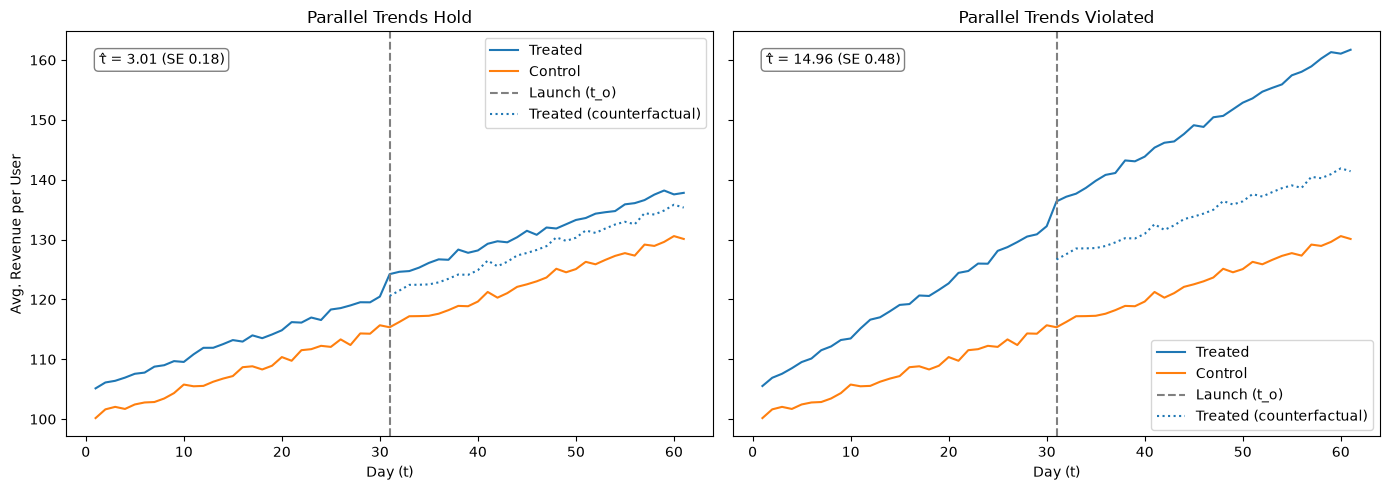

In [31]:
#Plot daily means
daily_means = geo_data.groupby(['D','t'],as_index=False).agg(
                                              revenue_right=('revenue_1','mean'),
                                              revenue_wrong=('revenue_2','mean'))

treated = daily_means[daily_means['D']==1]
control = daily_means[daily_means['D']==0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
# --- Panel 1: parallel trends (revenue_1) ---
axes[0].plot(treated['t'], treated['revenue_right'], label='Treated', color='C0')
axes[0].plot(control['t'], control['revenue_right'], label='Control', color='C1')
axes[0].axvline(t_o, color='gray', linestyle='--', label='Launch (t_o)')
 
# counterfactual: treated pre-trend + control's post-period change
pre_gap = (treated.loc[treated['t'] < t_o, 'revenue_right'].mean()
           - control.loc[control['t'] < t_o, 'revenue_right'].mean())
counterfactual = control.loc[control['t'] >= t_o, 'revenue_right'] + pre_gap
axes[0].plot(control.loc[control['t'] >= t_o, 't'], counterfactual,
             color='C0', linestyle=':', label='Treated (counterfactual)')
 
axes[0].set_title('Parallel Trends Hold')
axes[0].set_xlabel('Day (t)')
axes[0].set_ylabel('Avg. Revenue per User')
axes[0].legend()
axes[0].annotate(f'τ̂ = {tau_right:.2f} (SE {se_right:.2f})',
                  xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                  bbox=dict(boxstyle='round', fc='white', ec='gray'))
 
# --- Panel 2: violated trends (revenue_2) ---
axes[1].plot(treated['t'], treated['revenue_wrong'], label='Treated', color='C0')
axes[1].plot(control['t'], control['revenue_wrong'], label='Control', color='C1')
axes[1].axvline(t_o, color='gray', linestyle='--', label='Launch (t_o)')
 
pre_gap_w = (treated.loc[treated['t'] < t_o, 'revenue_wrong'].mean()
             - control.loc[control['t'] < t_o, 'revenue_wrong'].mean())
counterfactual_w = control.loc[control['t'] >= t_o, 'revenue_wrong'] + pre_gap_w
axes[1].plot(control.loc[control['t'] >= t_o, 't'], counterfactual_w,
             color='C0', linestyle=':', label='Treated (counterfactual)')
 
axes[1].set_title('Parallel Trends Violated')
axes[1].set_xlabel('Day (t)')
axes[1].legend()
axes[1].annotate(f'τ̂ = {tau_wrong:.2f} (SE {se_wrong:.2f})',
                  xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                  bbox=dict(boxstyle='round', fc='white', ec='gray'))
 
plt.tight_layout()
plt.savefig("G:/My Drive/Projects/Paralell Trends Violation/paralell_violation.png",
            dpi=300, bbox_inches='tight')
plt.show()